In [1]:
import torch
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.optim as optim
from torchmetrics import Precision, Recall

In [2]:
# Device configuration

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Model definition: simple CNN for 128x128 RGB images

class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
         # Feature extractor: 3 convolutional blocks

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Flatten())
        
        # Fully connected classifier

        self.classifier = nn.Linear(128*16*16, 256)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [4]:
# Instantiate model, loss, optimizer

model = Model(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [5]:
# Training transforms (with augmentation)

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Resize((128,128)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])

])

# Training dataset + dataloader

dataset_train = ImageFolder(
    'data/Rock-Paper-Scissors/train',
    transform = train_transforms
)

dataloader_train = DataLoader(
    dataset_train,
    shuffle=True,
    batch_size=64
)

In [6]:
# Visual sanity check: show one augmented image

image, label = next(iter(dataloader_train))
print(image.shape)
 
image = image[0].permute(1,2,0)
print(image.shape)

torch.Size([64, 3, 128, 128])
torch.Size([128, 128, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6183028].


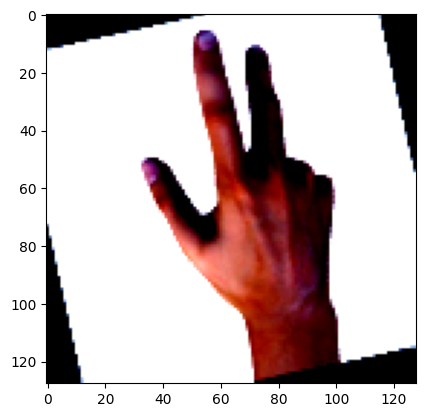

In [7]:
plt.imshow(image)
plt.show()

In [8]:
# Training loop

losses = []
epochs = 15

for epoch in range(epochs):
    running_loss = 0.0
    for image, label in dataloader_train:
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        
        outputs = model(image)
        loss = criterion(outputs, label)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(dataloader_train)
    losses.append(epoch_loss)
    print(f'Epoch loss {epoch+1}, Loss:{epoch_loss:.4f}')

Epoch loss 1, Loss:1.0785
Epoch loss 2, Loss:0.1824
Epoch loss 3, Loss:0.0820
Epoch loss 4, Loss:0.0551
Epoch loss 5, Loss:0.0757
Epoch loss 6, Loss:0.0327
Epoch loss 7, Loss:0.0263
Epoch loss 8, Loss:0.0272
Epoch loss 9, Loss:0.0519
Epoch loss 10, Loss:0.0207
Epoch loss 11, Loss:0.0366
Epoch loss 12, Loss:0.0199
Epoch loss 13, Loss:0.0183
Epoch loss 14, Loss:0.0279
Epoch loss 15, Loss:0.0078


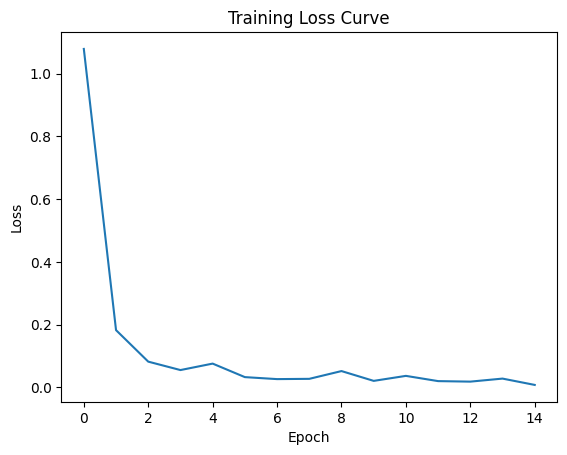

In [9]:
# Plot training loss

plt.plot(range(epochs), losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [10]:
# Test transforms (no augmentation)

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128,128)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])

])


# Test dataset + dataloader

dataset_test = ImageFolder(
    'data/Rock-Paper-Scissors/test',
    transform = test_transforms
)

dataloader_test = DataLoader(
    dataset_test,
    shuffle=True,
    batch_size=64,
    pin_memory=True)

In [11]:
# Macro precision & recall (averaged across classes)

metric_precision = Precision(
    task='multiclass',
    num_classes=3,
    average='macro'
).to(device)

metric_recall = Recall(
    task='multiclass',
    num_classes=3,
    average='macro'
).to(device)


model.eval()
with torch.no_grad():
    for image, label in dataloader_test:
        image = image.to(device)
        label = label.to(device)
        
        outputs = model(image)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, label)
        metric_recall(preds, label)

precision = metric_precision.compute()
recall = metric_recall.compute()

print(f'Macro Precison: {precision}')
print(f'Macro Recall: {recall}')

Macro Precison: 0.8748395442962646
Macro Recall: 0.852150559425354


In [12]:
# Per-class precision

metric_precision = Precision(
    task="multiclass",
    num_classes=3,
    average=None
).to(device)

model.eval()
with torch.no_grad():
    for image, label in dataloader_test:
        image = image.to(device)
        label = label.to(device)
        
        outputs = model(image)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, label)
precision = metric_precision.compute()

precision_per_class = {
    k: precision[v].item()
    for k, v 
    in dataset_test.class_to_idx.items()
}
print("Precision per class:", precision_per_class)

Precision per class: {'paper': 0.8684210777282715, 'rock': 1.0, 'scissors': 0.7560975551605225}


In [13]:
# Per-class recall

metric_recall = Recall(
    task="multiclass", num_classes=3, average=None
).to(device)

model.eval()
with torch.no_grad():
    for image, label in dataloader_test:
        image = image.to(device)
        label = label.to(device)
        
        outputs = model(image)
        _, preds = torch.max(outputs, 1)
        metric_recall(preds, label)
recall = metric_recall.compute()

# Get precision per class
recall_per_class = {
    k: recall[v].item()
    for k, v 
    in dataset_test.class_to_idx.items()
}
print("Recall per class:", recall_per_class)

Recall per class: {'paper': 0.7983871102333069, 'rock': 0.7580645084381104, 'scissors': 1.0}
